In [6]:
import glob
import os

import astropy.units as u
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sunpy.map
import sunpy.visualization.colormaps
from astropy.coordinates import SkyCoord
from astropy.time import Time
from sunpy.coordinates.sun import carrington_rotation_time
from sunpy.net import Fido
from sunpy.net import attrs as a
from tqdm.auto import tqdm

from ndcube import NDCube, NDMeta
from astropy.nddata import StdDevUncertainty

import asdf

In [6]:
outdir = '/Users/clowder/data/polar'
datadir = '/Users/clowder/data'

spacecraft = "sdo"
instrument = "aia"
wavelength = 193

outpath = f"{datadir}/{spacecraft}/{instrument}/{wavelength}/"

In [ ]:
cr = 2222
sample = 1

t0 = carrington_rotation_time(cr)
t1 = carrington_rotation_time(cr + 1.0)

t0_rounded = Time(np.ceil(t0.unix / 3600) * 3600, format="unix")
t1_rounded = Time(np.floor(t1.unix / 3600) * 3600, format="unix")

In [4]:
result = Fido.search(a.Time(t0_rounded, t1_rounded), a.jsoc.Series('aia.lev1_euv_12s'), a.jsoc.Segment('image'), 
                     a.Wavelength(wavelength * u.angstrom), a.Sample(sample*u.hour),a.jsoc.Notify("chris.lowder@swri.org"))

In [30]:
result = Fido.search(a.Time(t0_rounded, t1_rounded), a.Instrument.aia, a.Wavelength(wavelength * u.angstrom), a.Sample(sample*u.hour))

In [31]:
result

Start Time,End Time,Source,Instrument,Wavelength,Provider,Physobs,Wavetype,Extent Width,Extent Length,Extent Type,Size
,,,,Angstrom,,,,,,,Mibyte
Time,Time,str3,str3,float64[2],str4,str9,str6,str4,str4,str8,float64
2019-09-19 04:00:04.000,2019-09-19 04:00:05.000,SDO,AIA,193.0 .. 193.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2019-09-19 05:00:04.000,2019-09-19 05:00:05.000,SDO,AIA,193.0 .. 193.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2019-09-19 06:00:04.000,2019-09-19 06:00:05.000,SDO,AIA,193.0 .. 193.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2019-09-19 07:00:04.000,2019-09-19 07:00:05.000,SDO,AIA,193.0 .. 193.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2019-09-19 08:00:04.000,2019-09-19 08:00:05.000,SDO,AIA,193.0 .. 193.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2019-09-19 09:00:04.000,2019-09-19 09:00:05.000,SDO,AIA,193.0 .. 193.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2019-09-19 10:00:04.000,2019-09-19 10:00:05.000,SDO,AIA,193.0 .. 193.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2019-09-19 11:00:04.000,2019-09-19 11:00:05.000,SDO,AIA,193.0 .. 193.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844


In [32]:
files = Fido.fetch(result, path="/Users/clowder/data/scratch/")

Files Downloaded:   0%|          | 0/654 [00:00<?, ?file/s]



Files Downloaded:   0%|          | 0/654 [00:18<?, ?file/s]2026-04-14 16:16:56 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=193_1347940843-1347940843 failed to download with exception

2026-04-14 16:16:56 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=193_1347944443-1347944443 failed to download with exception

2026-04-14 16:16:56 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=193_1347948043-1347948043 failed to download with exception

2026-04-14 16:16:56 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=193_1347951643-1347951643 failed to download with exception

2026-04-14 16:16:56 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=r

5/0 files failed to download. Please check `.errors` for details


In [9]:
files = sorted(glob.glob(f"{outpath}/*.fits"))

In [10]:
out_shape=(4096,4096)
block_size=(1024,1024)

data_np = np.full(out_shape, np.nan)
data_sp = np.full(out_shape, np.nan)

for file in files[0:10]:
    aia_map = sunpy.map.Map(file)
    aia_map.data[...] = aia_map.data[...] / aia_map.meta['EXPTIME']

    obs_np = SkyCoord(0*u.deg, 90*u.deg, 1*u.AU, obstime=aia_map.date, frame='heliographic_carrington', observer='self')
    out_ref_coord_np = SkyCoord(0*u.arcsec, 0*u.arcsec, obstime=obs_np.obstime,
                            frame='helioprojective', observer=obs_np,
                            rsun=aia_map.coordinate_frame.rsun)
    out_header_np = sunpy.map.make_fitswcs_header(
        out_shape,
        out_ref_coord_np,
        scale=u.Quantity(aia_map.scale),
        instrument=aia_map.instrument,
        wavelength=aia_map.wavelength
    )
    outmap_np = aia_map.reproject_to(out_header_np, algorithm='adaptive', block_size=block_size, parallel=True)

    obs_sp = SkyCoord(0*u.deg, -90*u.deg, 1*u.AU, obstime=aia_map.date, frame='heliographic_carrington', observer='self')
    out_ref_coord_sp = SkyCoord(0*u.arcsec, 0*u.arcsec, obstime=obs_sp.obstime,
                            frame='helioprojective', observer=obs_sp,
                            rsun=aia_map.coordinate_frame.rsun)
    out_header_sp = sunpy.map.make_fitswcs_header(
        out_shape,
        out_ref_coord_sp,
        scale=u.Quantity(aia_map.scale),
        instrument=aia_map.instrument,
        wavelength=aia_map.wavelength
    )
    outmap_sp = aia_map.reproject_to(out_header_sp, algorithm='adaptive', block_size=block_size, parallel=True)

    data_np = np.fmin(data_np, outmap_np.data*(outmap_np.data!=0))
    data_sp = np.fmin(data_sp, outmap_sp.data*(outmap_sp.data!=0))

cmap = f"sdoaia{aia_map.wavelength.value.astype(int)}"
wavelength = aia_map.wavelength.value.astype(int)

map_np = sunpy.map.Map(data_np, out_header_np)
map_sp = sunpy.map.Map(data_sp, out_header_sp)

map_np.save(outdir + f"cr{cr}-np-{wavelength}A.fits")
map_sp.save(outdir + f"cr{cr}-sp-{wavelength}A.fits")

fig, ax = plt.subplots(figsize=(9.5, 7.5), subplot_kw={'projection':outmap_np.wcs})

im = ax.imshow(data_np, cmap=matplotlib.colormaps[cmap], vmin=0, vmax=140)

ax.set_facecolor('black')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"North Pole - SDO/AIA - {wavelength}$\\AA$ - CR {cr}")
fig.colorbar(im, ax=ax, label='min(DN/s)', extend='max')

plt.savefig(f"./plt/cr{cr}-np-{wavelength}A.pdf")
plt.savefig(f"./plt/cr{cr}-np-{wavelength}A.png", dpi=300)

plt.close()

fig, ax = plt.subplots(figsize=(9.5, 7.5), subplot_kw={'projection':outmap_sp.wcs})

im = ax.imshow(data_sp, cmap=matplotlib.colormaps[cmap], vmin=0, vmax=140)

ax.set_facecolor('black')
# ax.coords.grid(color='white', alpha=.25, ls='dotted')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"South Pole - SDO/AIA - 193$\\AA$ - CR {cr}")
fig.colorbar(im, ax=ax, label='min(DN/s)', extend='max')

plt.savefig(f"./plt/cr{cr}-sp-{wavelength}A.pdf")
plt.savefig(f"./plt/cr{cr}-sp-{wavelength}A.png", dpi=300)

plt.close()

2026-04-13 15:18:36 - reproject.common - INFO: Broadcasting is not being used
2026-04-13 15:18:36 - reproject.common - INFO: Not parallelizing along broadcasted dimension (block_size=(1024, 1024), shape_out=(4096, 4096))
2026-04-13 15:18:36 - reproject.common - INFO: Setting up output dask array with map_blocks
2026-04-13 15:18:36 - reproject.common - INFO: Computing output array directly to zarr array at /var/folders/6f/n6wcm_dd6s7b6mqr3h6n18d40000gp/T/tmpswog3kb2/222ac714-dfcf-4b9f-a022-27edda725960.zarr
2026-04-13 15:18:42 - reproject.common - INFO: Copying output zarr array into output Numpy arrays
2026-04-13 15:18:42 - reproject.common - INFO: Broadcasting is not being used
2026-04-13 15:18:42 - reproject.common - INFO: Not parallelizing along broadcasted dimension (block_size=(1024, 1024), shape_out=(4096, 4096))
2026-04-13 15:18:42 - reproject.common - INFO: Setting up output dask array with map_blocks
2026-04-13 15:18:42 - reproject.common - INFO: Computing output array directl

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from aia_process import process_file

data_np = np.full(out_shape, np.nan)
data_sp = np.full(out_shape, np.nan)

with ProcessPoolExecutor() as executor:
    futures = {executor.submit(process_file, f, out_shape, block_size): f
               for f in files[::2]}
    for future in as_completed(futures):
        res = future.result()
        data_np = np.fmin(data_np, res['np'][0])
        data_sp = np.fmin(data_sp, res['sp'][0])
        out_header_np = res['np'][1]
        out_header_sp = res['sp'][1]

/Users/clowder/work/polar/aia_process.py:9: RuntimeWarning: divide by zero encountered in divide
  aia_map.data[...] = aia_map.data[...] / aia_map.meta['EXPTIME']
/Users/clowder/work/polar/aia_process.py:9: RuntimeWarning: invalid value encountered in divide
  aia_map.data[...] = aia_map.data[...] / aia_map.meta['EXPTIME']
/Users/clowder/work/polar/aia_process.py:9: RuntimeWarning: divide by zero encountered in divide
  aia_map.data[...] = aia_map.data[...] / aia_map.meta['EXPTIME']
/Users/clowder/work/polar/aia_process.py:9: RuntimeWarning: invalid value encountered in divide
  aia_map.data[...] = aia_map.data[...] / aia_map.meta['EXPTIME']
/Users/clowder/work/polar/aia_process.py:9: RuntimeWarning: divide by zero encountered in divide
  aia_map.data[...] = aia_map.data[...] / aia_map.meta['EXPTIME']
/Users/clowder/work/polar/aia_process.py:9: RuntimeWarning: invalid value encountered in divide
  aia_map.data[...] = aia_map.data[...] / aia_map.meta['EXPTIME']
/Users/clowder/work/polar

In [18]:
cmap = f"sdoaia{aia_map.wavelength.value.astype(int)}"
wavelength = aia_map.wavelength.value.astype(int)

map_np = sunpy.map.Map(data_np, out_header_np)
map_sp = sunpy.map.Map(data_sp, out_header_sp)

map_np.save(f"{outdir}/cr{cr}-np-{wavelength}A.fits", overwrite=True)
map_sp.save(f"{outdir}/cr{cr}-sp-{wavelength}A.fits", overwrite=True)

fig, ax = plt.subplots(figsize=(9.5, 7.5), subplot_kw={'projection':outmap_np.wcs})

im = ax.imshow(data_np, cmap=matplotlib.colormaps[cmap], vmin=0, vmax=140)

ax.set_facecolor('black')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"North Pole - SDO/AIA - {wavelength}$\\AA$ - CR {cr}")
fig.colorbar(im, ax=ax, label='min(DN/s)', extend='max')

plt.savefig(f"./plt/cr{cr}-np-{wavelength}A.pdf")
plt.savefig(f"./plt/cr{cr}-np-{wavelength}A.png", dpi=300)

plt.close()

fig, ax = plt.subplots(figsize=(9.5, 7.5), subplot_kw={'projection':outmap_sp.wcs})

im = ax.imshow(data_sp, cmap=matplotlib.colormaps[cmap], vmin=0, vmax=140)

ax.set_facecolor('black')
# ax.coords.grid(color='white', alpha=.25, ls='dotted')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"South Pole - SDO/AIA - 193$\\AA$ - CR {cr}")
fig.colorbar(im, ax=ax, label='min(DN/s)', extend='max')

plt.savefig(f"./plt/cr{cr}-sp-{wavelength}A.pdf")
plt.savefig(f"./plt/cr{cr}-sp-{wavelength}A.png", dpi=300)

plt.close()

In [2]:
datadir = "/Users/clowder/data/polar/"
cr = 2122
wave = 193

data = asdf.load(f"{datadir}cr{cr}-193A.asdf")

Observatory,
Instrument,AIA 2
Detector,AIA
Measurement,193.0 Angstrom
Wavelength,193.0 Angstrom
Observation Date,2012-04-28 04:00:07
Exposure Time,Unknown
Dimension,[4096. 4096.] pix
Coordinate System,helioprojective
Scale,[0.60075802 0.60075802] arcsec / pix
Reference Pixel,[2047.5 2047.5] pix

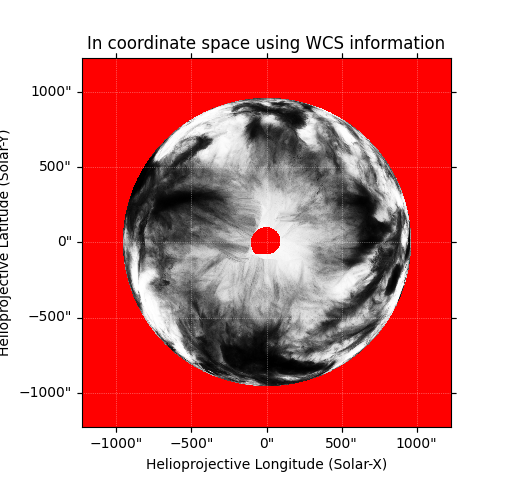
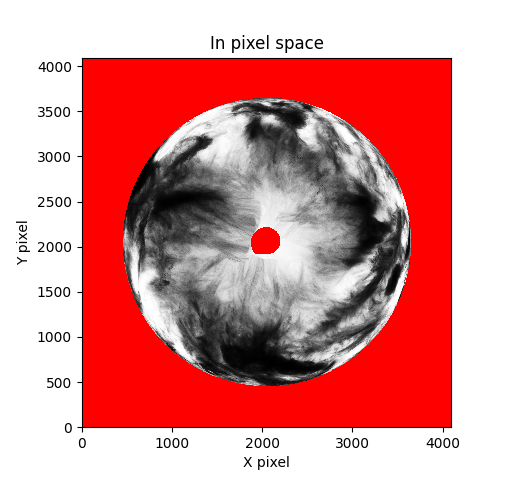
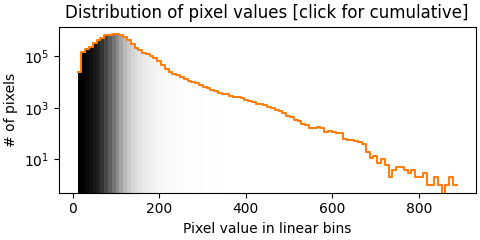
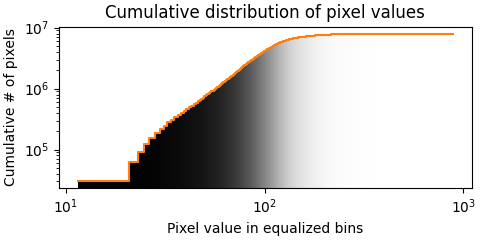

In [ ]:
data["map_np"]

In [17]:
outdir = "/Users/clowder/data/polar/"
wavelength = 193

map_np = data["map_np"]
map_sp = data["map_sp"]

data_np = NDCube(data=map_np.data, wcs=map_np.wcs, uncertainty=StdDevUncertainty(np.sqrt(map_np.data)), meta=dict(map_np.meta))
data_sp = NDCube(data=map_sp.data, wcs=map_sp.wcs, uncertainty=StdDevUncertainty(np.sqrt(map_sp.data)), meta=dict(map_sp.meta))

tree = {
    "map_np": data_np,
    "map_sp": data_sp,
}

af = asdf.AsdfFile(tree)
af.write_to(f"{outdir}/cr{cr}-{wavelength}A_ndcube.asdf", all_array_compression="zlib")

In [ ]:
def generate_polarmap(cr:int, 
                      wave:int = 193, 
                      datadir:str = '/Users/clowder/data/aia_rotation/') -> None:
    """Generate polar map from input EUV data."""
    t0 = carrington_rotation_time(cr)
    t1 = carrington_rotation_time(cr+1)

    result = Fido.search(a.Time(t0, t1), a.Instrument.aia, a.Wavelength(wave * u.angstrom), a.Sample(1*u.day))

    files = Fido.fetch(result, path=datadir)

    out_shape=(4096,4096)
    block_size=(1024,1024)

    data_np = np.full(out_shape, np.nan)
    data_sp = np.full(out_shape, np.nan)

    for file in files:
        aia_map = sunpy.map.Map(file)
        aia_map.data[...] = aia_map.data[...] / aia_map.meta['EXPTIME']

        obs_np = SkyCoord(0*u.deg, 90*u.deg, 1*u.AU, obstime=aia_map.date, frame='heliographic_carrington', observer='self')
        out_ref_coord_np = SkyCoord(0*u.arcsec, 0*u.arcsec, obstime=obs_np.obstime,
                                frame='helioprojective', observer=obs_np,
                                rsun=aia_map.coordinate_frame.rsun)
        out_header_np = sunpy.map.make_fitswcs_header(
            out_shape,
            out_ref_coord_np,
            scale=u.Quantity(aia_map.scale),
            instrument=aia_map.instrument,
            wavelength=aia_map.wavelength
        )
        outmap_np = aia_map.reproject_to(out_header_np, algorithm='adaptive', block_size=block_size, parallel=True)

        obs_sp = SkyCoord(0*u.deg, -90*u.deg, 1*u.AU, obstime=aia_map.date, frame='heliographic_carrington', observer='self')
        out_ref_coord_sp = SkyCoord(0*u.arcsec, 0*u.arcsec, obstime=obs_sp.obstime,
                                frame='helioprojective', observer=obs_sp,
                                rsun=aia_map.coordinate_frame.rsun)
        out_header_sp = sunpy.map.make_fitswcs_header(
            out_shape,
            out_ref_coord_sp,
            scale=u.Quantity(aia_map.scale),
            instrument=aia_map.instrument,
            wavelength=aia_map.wavelength
        )
        outmap_sp = aia_map.reproject_to(out_header_sp, algorithm='adaptive', block_size=block_size, parallel=True)

        data_np = np.fmin(data_np, outmap_np.data*(outmap_np.data!=0))
        data_sp = np.fmin(data_sp, outmap_sp.data*(outmap_sp.data!=0))
    
    cmap = f"sdoaia{aia_map.wavelength.value.astype(int)}"
    wavelength = aia_map.wavelength.value.astype(int)

    map_np = sunpy.map.Map(data_np, out_header_np)
    map_sp = sunpy.map.Map(data_sp, out_header_sp)

    map_np.save(outdir + f"cr{cr}-np-{wavelength}A.fits")
    map_sp.save(outdir + f"cr{cr}-sp-{wavelength}A.fits")

    fig, ax = plt.subplots(figsize=(9.5, 7.5), subplot_kw={'projection':outmap_np.wcs})

    im = ax.imshow(data_np, cmap=matplotlib.colormaps[cmap], vmin=0, vmax=140)

    ax.set_facecolor('black')
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(f"North Pole - SDO/AIA - {wavelength}$\\AA$ - CR {cr}")
    fig.colorbar(im, ax=ax, label='min(DN/s)', extend='max')

    plt.savefig(f"./plt/cr{cr}-np-{wavelength}A.pdf")
    plt.savefig(f"./plt/cr{cr}-np-{wavelength}A.png", dpi=300)

    plt.close()

    fig, ax = plt.subplots(figsize=(9.5, 7.5), subplot_kw={'projection':outmap_sp.wcs})

    im = ax.imshow(data_sp, cmap=matplotlib.colormaps[cmap], vmin=0, vmax=140)

    ax.set_facecolor('black')
    # ax.coords.grid(color='white', alpha=.25, ls='dotted')
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(f"South Pole - SDO/AIA - 193$\\AA$ - CR {cr}")
    fig.colorbar(im, ax=ax, label='min(DN/s)', extend='max')

    plt.savefig(f"./plt/cr{cr}-sp-{wavelength}A.pdf")
    plt.savefig(f"./plt/cr{cr}-sp-{wavelength}A.png", dpi=300)

    plt.close()